In [1]:
import numpy as np
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([5, 6, 10, 13, 11], dtype=float)
b0 = 3.3
b1 = 1.19
lr = 0.1
def batch_gradient_descent(X, Y, b0, b1, lr, iterations=10):
    n = len(X)

    print("---- Batch Gradient Descent ----") 
    for i in range(iterations):
        y_pred = b0 + b1 * X
        db0 = (-2/n) * np.sum(Y - y_pred)
        db1 = (-2/n) * np.sum((Y - y_pred) * X)
        b0 = b0 - lr * db0
        b1 = b1 - lr * db1

        print(f"Iter {i+1}: b0 = {b0:.4f}, b1 = {b1:.4f}")

    return b0, b1
def stochastic_gradient_descent(X, Y, b0, b1, lr, iterations=10):
    n = len(X)

    print("\n---- Stochastic Gradient Descent ----")
    for i in range(iterations):
        for j in range(n):  
            xj = X[j]
            yj = Y[j]
            y_pred = b0 + b1 * xj
            db0 = -2 * (yj - y_pred)
            db1 = -2 * (yj - y_pred) * xj
            b0 -= lr * db0
            b1 -= lr * db1

        print(f"Iter {i+1}: b0 = {b0:.4f}, b1 = {b1:.4f}")

    return b0, b1

batch_gradient_descent(X, Y, 3.3, 1.19, lr=0.1)
stochastic_gradient_descent(X, Y, 3.3, 1.19, lr=0.1)

---- Batch Gradient Descent ----
Iter 1: b0 = 3.7260, b1 = 2.7520
Iter 2: b0 = 3.1296, b1 = 0.6220
Iter 3: b0 = 3.9305, b1 = 3.5358
Iter 4: b0 = 2.8229, b1 = -0.4413
Iter 5: b0 = 4.3231, b1 = 4.9958
Iter 6: b0 = 2.2610, b1 = -2.4288
Iter 7: b0 = 5.0661, b1 = 7.7180
Iter 8: b0 = 1.2220, b1 = -6.1413
Iter 9: b0 = 6.4624, b1 = 12.7963
Iter 10: b0 = -0.7079, b1 = -13.0730

---- Stochastic Gradient Descent ----
Iter 1: b0 = 4.1149, b1 = 4.2915
Iter 2: b0 = 2.9676, b1 = 3.6420
Iter 3: b0 = 2.3134, b1 = 3.2717
Iter 4: b0 = 1.9403, b1 = 3.0605
Iter 5: b0 = 1.7276, b1 = 2.9401
Iter 6: b0 = 1.6062, b1 = 2.8715
Iter 7: b0 = 1.5371, b1 = 2.8323
Iter 8: b0 = 1.4976, b1 = 2.8100
Iter 9: b0 = 1.4751, b1 = 2.7972
Iter 10: b0 = 1.4623, b1 = 2.7900


(np.float64(1.4622922201777067), np.float64(2.7899767284024755))

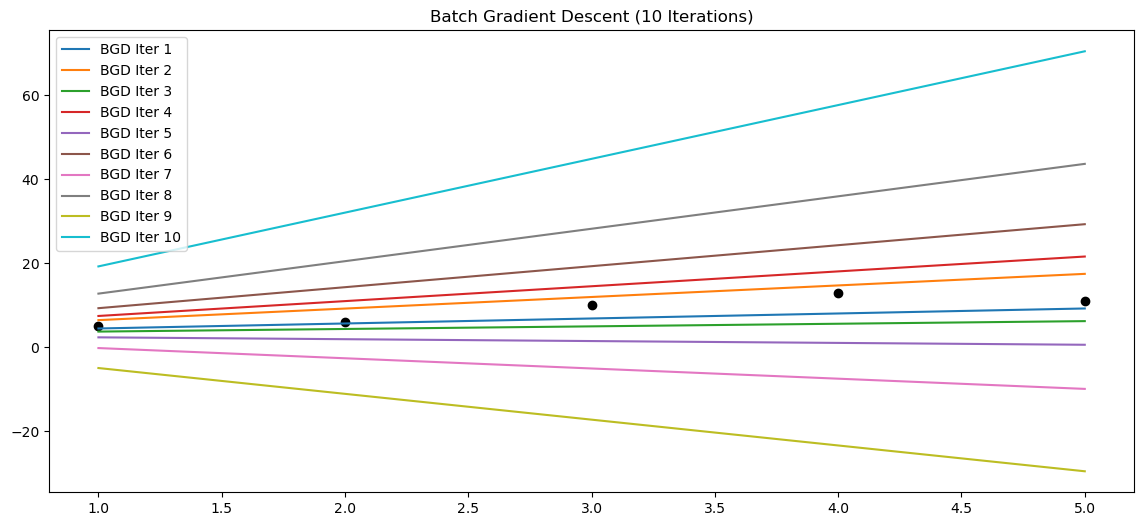

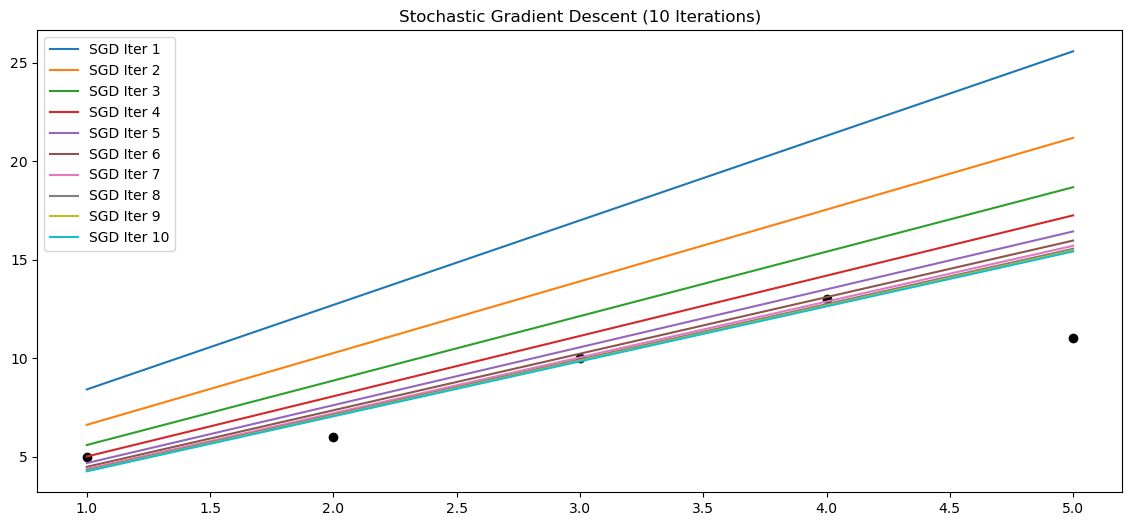

In [2]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([5, 6, 10, 13, 11], dtype=float)


b0 = 3.3
b1 = 1.19
lr = 0.1


def batch_gradient_descent(X, Y, b0, b1, lr, iterations=10):
    n = len(X)
    history = []

    for i in range(iterations):
        y_pred = b0 + b1 * X

       
        db0 = (-2/n) * np.sum(Y - y_pred)
        db1 = (-2/n) * np.sum((Y - y_pred) * X)

        
        b0 = b0 - lr * db0
        b1 = b1 - lr * db1

      
        history.append((b0, b1, y_pred))

    return b0, b1, history


# -------- Stochastic Gradient Descent --------
def stochastic_gradient_descent(X, Y, b0, b1, lr, iterations=10):
    n = len(X)
    history = []

    for i in range(iterations):
        for j in range(n):   # take one sample at a time
            xj = X[j]
            yj = Y[j]
            y_pred = b0 + b1 * xj

            # Gradients
            db0 = -2 * (yj - y_pred)
            db1 = -2 * (yj - y_pred) * xj

            # Update parameters
            b0 -= lr * db0
            b1 -= lr * db1

        # Store each epoch
        y_pred_full = b0 + b1 * X
        history.append((b0, b1, y_pred_full))

    return b0, b1, history


# ---- Run BGD ----
b0_bgd, b1_bgd, bgd_hist = batch_gradient_descent(X, Y, b0, b1, lr)

# ---- Run SGD ----
b0_sgd, b1_sgd, sgd_hist = stochastic_gradient_descent(X, Y, b0, b1, lr)

# ---- Plotting ----
plt.figure(figsize=(14, 6))

# Batch GD plot
for i, (_, _, y_pred) in enumerate(bgd_hist):
    plt.plot(X, y_pred, label=f'BGD Iter {i+1}')

plt.scatter(X, Y, color='black')
plt.title("Batch Gradient Descent (10 Iterations)")
plt.legend()
plt.show()

# SGD plot
plt.figure(figsize=(14, 6))

for i, (_, _, y_pred) in enumerate(sgd_hist):
    plt.plot(X, y_pred, label=f'SGD Iter {i+1}')

plt.scatter(X, Y, color='black')
plt.title("Stochastic Gradient Descent (10 Iterations)")
plt.legend()
plt.show()
